In [7]:
from qick import *
import numpy as np
%pylab inline
soc = QickSoc()
soccfg = soc
GEN_CH = 0
RO_CH = 0

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [8]:
import inspect
class CPMGLoopback(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
#         print(cfg)
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)
        
        # configure the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"])

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)
        
        style=self.cfg["pulse_style"]
        pi_len = self.cfg["pi"] * 2 # 1ns / sample
        half_pi = int(0.5 * pi_len)
        tau_len = self.cfg["tau"] * 2 # 1ns / sample
        two_tau = 2 * tau_len
        train_sequence = self.cfg["train"]
        
        if style in ["cpmg"]:
            idata = np.zeros(2**16)
            qdata = np.zeros(2**16)
            iq_index = 0 # variable for stepping through and setting I and Q data
            for i, step in enumerate(train_sequence):
                if step == "half_X":
                    idata[iq_index:half_pi + iq_index] = 1
                    iq_index += half_pi
                elif step == "X":
                    iq_index += tau_len
                    idata[iq_index:pi_len + iq_index] = 1
                    iq_index += pi_len + tau_len
                elif step == "Y":
                    iq_index += tau_len
                    qdata[iq_index:pi_len + iq_index] = 1
                    iq_index += pi_len + tau_len
            idata = idata[:((iq_index + 15) // 16) * 16] # sample only up to nearest multiple of 16
            qdata = qdata[:((iq_index + 15) // 16) * 16] # sample only up to nearest multiple of 16
            idata*=self.soccfg.get_maxv(res_ch)
            qdata*=self.soccfg.get_maxv(res_ch)
            self.add_envelope(ch=res_ch, name="measure", idata=idata, qdata=qdata)
            self.set_pulse_registers(ch=res_ch, style="arb", waveform="measure")
        self.synci(200)  # give processor some time to configure pulses
        
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
#         self.measure(pulse_ch=self.cfg["res_ch"], 
#                      adcs=self.ro_chs,
#                      pins=[0], 
#                      adc_trig_offset=self.cfg["adc_trig_offset"],
#                      wait=True,
#                      syncdelay=self.us2cycles(self.cfg["relax_delay"]))
        
        # equivalent to the following:
        self.trigger(adcs=self.ro_chs,
                     pins=[0], 
                    adc_trig_offset=self.cfg["adc_trig_offset"])
        self.pulse(ch=self.cfg["res_ch"])
        self.wait_all()
        self.sync_all(self.us2cycles(self.cfg["relax_delay"]))

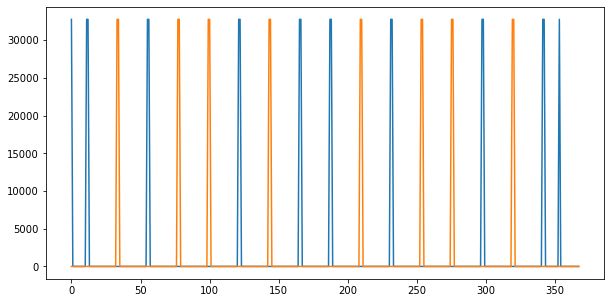

In [18]:
config={"res_ch":GEN_CH, # --Fixed
        "ro_chs":[RO_CH], # --Fixed
        "reps":1, # --Fixed
        "relax_delay":1.0, # --us
        "res_phase":90, # --degrees
        "pulse_style": "cpmg", # --Fixed
        
        "train":["half_X","X","Y","X","Y","Y","X","Y","X","half_X"],
        "pi":1, # ns
        "tau":5, # ns
        
        "readout_length":1000, # [Clock ticks]
        "pulse_gain":3000, # [DAC units]
        "pulse_freq": 250, # [MHz]
        "adc_trig_offset": 100, # [Clock ticks]
        "soft_avgs":10,        
       }
prog = CPMGLoopback(soccfg, config)
# print(prog)
iq_list1 = prog1.acquire_decimated(soc, progress=False)
plt.plot(np.array(prog1.envelopes[0]['envs']['measure']['data'])[:, 0])
plt.plot(np.array(prog1.envelopes[0]['envs']['measure']['data'])[:, 1])

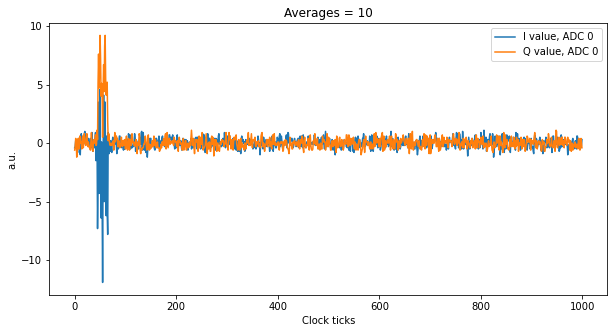

In [19]:
# Plot results.
plt.figure(1)
for ii, iq in enumerate(iq_list1):
    plt.plot(iq[0], label="I value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(iq[1], label="Q value, ADC %d"%(config['ro_chs'][ii]))
#     plt.plot(np.abs(iq[0]+1j*iq[1]), label="mag, ADC %d"%(config['ro_chs'][ii]))
plt.ylabel("a.u.")


plt.xlabel("Clock ticks")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend();
plt.rcParams['figure.figsize'] = [10, 5]